### 학습이 끝난 후 모델별로 점수 작성해놓기(보고서 작성 위함)

In [ ]:
import numpy as np
import pandas as pd
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import *

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import random
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf

In [2]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size=32):
    """    pandas/numpy 데이터를 PyTorch 학습용 DataLoader와 검증 텐서로 변환합니다."""

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, x_val_tensor, y_val_tensor


def train(dataloader, model, loss_fn, optimizer, device):
    """한 epoch 동안 모델을 학습하고 평균 train loss를 반환합니다."""
    model.train()                               # 훈련 모드로 설정
    total_loss = 0

    for x, y in dataloader:                # (X, y) : 입력 데이터와 레이블
        x, y = x.to(device), y.to(device)  # 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 연결

        # Feed Forward
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지. 한 배치를 시작할 때 이전 배치의 gradient를 먼저 지우고, 현재 배치의 gradient만 계산
        pred = model(x)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()         # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()        # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트

        total_loss += loss.item() * x.size(0)       # 배치 평균 loss에 배치 크기를 곱해 배치 전체 loss로 누적


    return total_loss / len(dataloader.dataset)     # 전체 데이터 개수로 나누어 epoch 평균 loss 반환



def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    """검증 데이터 전체에 대한 loss와 예측값을 반환합니다."""

    model.eval()         # 모델을 평가 모드로 설정

    with torch.no_grad():       # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x = x_val_tensor.to(device)
        y = y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item() # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred


def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = range(1, len(tr_loss_list) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, tr_loss_list, label="train_loss", marker=".")
    plt.plot(epochs, val_loss_list, label="val_loss", marker=".")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# =================================== MultiTask 용========================================
def make_multitask_dataset(
    x_train,
    x_val,
    y_reg_train,
    y_reg_val,
    y_cls_train,
    y_cls_val,
    batch_size=32
):
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)

    y_reg_train_tensor = torch.tensor(y_reg_train.values, dtype=torch.float32).view(-1, 1)
    y_reg_val_tensor = torch.tensor(y_reg_val.values, dtype=torch.float32).view(-1, 1)

    y_cls_train_tensor = torch.tensor(y_cls_train.values, dtype=torch.long)
    y_cls_val_tensor = torch.tensor(y_cls_val.values, dtype=torch.long)

    train_dataset = TensorDataset(
        x_train_tensor,
        y_reg_train_tensor,
        y_cls_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    return train_loader, x_val_tensor, y_reg_val_tensor, y_cls_val_tensor

def train_multitask(
    dataloader,
    model,
    reg_loss_fn,
    cls_loss_fn,
    optimizer,
    device,
    alpha=1.0,
    beta=0.3
):
    model.train()
    total_loss = 0

    for x, y_reg, y_cls in dataloader:
        x = x.to(device)
        y_reg = y_reg.to(device)
        y_cls = y_cls.to(device)

        optimizer.zero_grad()

        reg_pred, cls_pred = model(x)

        reg_loss = reg_loss_fn(reg_pred, y_reg)
        cls_loss = cls_loss_fn(cls_pred, y_cls)

        loss = alpha * reg_loss + beta * cls_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(dataloader.dataset)

def evaluate_multitask(
    x_val_tensor,
    y_reg_val_tensor,
    y_cls_val_tensor,
    model,
    reg_loss_fn,
    cls_loss_fn,
    device,
    alpha=1.0,
    beta=0.3
):
    model.eval()

    with torch.no_grad():
        x = x_val_tensor.to(device)
        y_reg = y_reg_val_tensor.to(device)
        y_cls = y_cls_val_tensor.to(device)

        reg_pred, cls_pred = model(x)

        reg_loss = reg_loss_fn(reg_pred, y_reg)
        cls_loss = cls_loss_fn(cls_pred, y_cls)

        loss = alpha * reg_loss + beta * cls_loss

    return loss.item(), reg_pred, cls_pred

def evaluate_multitask_metrics(
    model,
    x_val_tensor,
    y_reg_val_tensor,
    y_cls_val_tensor,
    device
):
    model.eval()

    with torch.no_grad():
        reg_pred, cls_pred = model(x_val_tensor.to(device))

    y_reg_pred = reg_pred.cpu().numpy().flatten()
    y_reg_true = y_reg_val_tensor.cpu().numpy().flatten()

    y_cls_pred = torch.argmax(cls_pred, dim=1).cpu().numpy()
    y_cls_true = y_cls_val_tensor.cpu().numpy()

    mse = mean_squared_error(y_reg_true, y_reg_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_reg_true, y_reg_pred)
    r2 = r2_score(y_reg_true, y_reg_pred)

    acc = accuracy_score(y_cls_true, y_cls_pred)

    print("Regression")
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

    print("\nClassification")
    print("Accuracy:", acc)
    print(confusion_matrix(y_cls_true, y_cls_pred))
    print(classification_report(y_cls_true, y_cls_pred))

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "accuracy": acc,
        "y_reg_true": y_reg_true,
        "y_reg_pred": y_reg_pred,
        "y_cls_true": y_cls_true,
        "y_cls_pred": y_cls_pred,
    }

def parse_json_list(value):
    """JSON 문자열(list[dict])을 파이썬 list로 변환."""
    if pd.isna(value) or value == "":
        return []

    try:
        parsed = json.loads(value)
        return parsed if isinstance(parsed, list) else []
    except json.JSONDecodeError:
        return []


def parse_json_dict(value):
    """JSON 문자열(dict)을 파이썬 dict로 변환."""
    if pd.isna(value) or value == "":
        return {}

    try:
        parsed = json.loads(value)
        return parsed if isinstance(parsed, dict) else {}
    except json.JSONDecodeError:
        return {}
    
class MultiTaskMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(0.25)
        )

        self.reg_head = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

        self.cls_head = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        shared_out = self.shared(x)
        return self.reg_head(shared_out), self.cls_head(shared_out)

# 피처 조합
- data: v3

In [3]:
df = pd.read_csv('data/processed/feature_table_v3.csv')
pd.set_option("display.max_info_columns", 1000)
pd.set_option("display.max_columns", 1000)

df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 3869 entries, 0 to 3868
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   movie_id                 3869 non-null   str    
 1   title                    3869 non-null   str    
 2   runtime                  3869 non-null   float64
 3   rating_encoded           3869 non-null   float64
 4   is_korean                3869 non-null   float64
 5   genre                    3869 non-null   str    
 6   open_date                3869 non-null   str    
 7   open_month               3869 non-null   float64
 8   open_day_of_week         3869 non-null   float64
 9   is_summer                3869 non-null   int64  
 10  is_winter                3869 non-null   int64  
 11  is_holiday_release       3869 non-null   int64  
 12  holiday_nearby_count     3869 non-null   int64  
 13  director_avg_audi        3869 non-null   float64
 14  director_movie_count     3869 non-n

In [4]:
def add_engineered_features(df):
    df = df.copy()

    # 날짜 처리
    df["open_date"] = pd.to_datetime(df["open_date"], errors="coerce")
    df["open_year"] = df["open_date"].dt.year
    df["open_quarter"] = df["open_date"].dt.quarter

    # 1. 시즌 피처 강화
    df["is_peak_season"] = (
        (df["is_summer"] == 1) | (df["is_winter"] == 1)
    ).astype(int)

    df["season_type"] = "normal"
    df.loc[df["is_summer"] == 1, "season_type"] = "summer"
    df.loc[df["is_winter"] == 1, "season_type"] = "winter"

    # 개봉 요일 그룹
    # 0 월, 1 화, 2 수, 3 목, 4 금, 5 토, 6 일
    df["release_day_group"] = "other"
    df.loc[df["open_day_of_week"].isin([2, 3]), "release_day_group"] = "wed_thu"
    df.loc[df["open_day_of_week"].isin([4, 5, 6]), "release_day_group"] = "weekend_near"

    # 2. 장르 x 시즌 / 장르 x 국적 조합
    df["genre_season"] = df["genre"].astype(str) + "_" + df["season_type"].astype(str)
    df["genre_korean"] = df["genre"].astype(str) + "_" + df["is_korean"].astype(int).astype(str)

    # 3. Star Power 묶음
    star_cols = [
        "director_avg_audi",
        "lead_actor_avg_audi",
        "cast_max_star_power",
    ]
    df["star_power_mean"] = df[star_cols].mean(axis=1)
    df["star_power_max"] = df[star_cols].max(axis=1)
    df["star_power_log"] = np.log1p(df["star_power_max"])

    df["star_experience_total"] = (
        df["director_movie_count"] + df["lead_actor_movie_count"]
    )

    # 4. Brand Power 묶음
    brand_cols = [
        "distributor_avg_audi",
        "producer_avg_audi",
    ]
    df["brand_power_mean"] = df[brand_cols].mean(axis=1)
    df["brand_power_max"] = df[brand_cols].max(axis=1)
    df["brand_power_log"] = np.log1p(df["brand_power_max"])

    df["brand_experience_total"] = (
        df["distributor_movie_count"] + df["producer_movie_count"]
    )

    # 5. 시장 x 시즌 조합
    # market_avg_audi_7d는 개봉 직전 시장 상황이라 개봉 전 예측에도 비교적 안전한 피처
    df["peak_season_market"] = df["is_peak_season"] * df["market_avg_audi_7d"]
    df["holiday_market"] = df["is_holiday_release"] * df["market_avg_audi_7d"]

    # 6. 네이버 트렌드 강화
    df["trend_pre7_avg_log"] = np.log1p(df["trend_pre7_avg"])
    df["trend_pre7_max_log"] = np.log1p(df["trend_pre7_max"])

    df["trend_peak_gap"] = df["trend_pre7_max"] - df["trend_pre7_avg"]
    df["trend_peak_ratio"] = df["trend_pre7_max"] / (df["trend_pre7_avg"] + 1e-6)

    df["trend_strength"] = (
        df["has_trend_data"] * df["trend_pre7_avg_log"]
    )

    # 7. 경쟁 강도 보정
    df["competition_market_pressure"] = (
        df["same_week_releases"] * df["market_avg_audi_7d"]
    )

    return df


df_fe = add_engineered_features(df)

print("원본 shape:", df.shape)
print("피처 보강 후 shape:", df_fe.shape)

new_cols = [c for c in df_fe.columns if c not in df.columns]
print("추가된 피처:")
for c in new_cols:
    print("-", c)

원본 shape: (3869, 38)
피처 보강 후 shape: (3869, 61)
추가된 피처:
- open_year
- open_quarter
- is_peak_season
- season_type
- release_day_group
- genre_season
- genre_korean
- star_power_mean
- star_power_max
- star_power_log
- star_experience_total
- brand_power_mean
- brand_power_max
- brand_power_log
- brand_experience_total
- peak_season_market
- holiday_market
- trend_pre7_avg_log
- trend_pre7_max_log
- trend_peak_gap
- trend_peak_ratio
- trend_strength
- competition_market_pressure


In [5]:
df[['trend_growth_rate','trend_pre7_avg']].max()

trend_growth_rate     4.207528
trend_pre7_avg       87.855714
dtype: float64

In [6]:
# 코로나 전후 관객 측정
df["open_date"] = pd.to_datetime(df["open_date"], errors="coerce")
df["open_year"] = df["open_date"].dt.year

def get_release_period(year):
    if year <= 2019:
        return "pre_covid"
    elif year <= 2022:
        return "covid"
    else:
        return "post_covid"

df["release_period"] = df["open_year"].apply(get_release_period)

df["is_covid_period"] = (df["release_period"] == "covid").astype(int)


In [7]:
df = df.drop(columns=["is_post_covid"], errors="ignore")

In [8]:
#========================코로나 입력 완료============================
#========================피크 시즌 조정 ===========================

In [9]:
# 임시 분석용 컬럼
df["is_peak_season_tmp"] = (
    (df["is_summer"] == 1) | (df["is_winter"] == 1)
).astype(int)

season_summary = (
    df.groupby("is_peak_season_tmp")["total_audience"]
      .agg(
          count="count",
          mean="mean",
          median="median",
          std="std",
          min="min",
          max="max"
      )
)

season_summary

df["season_group_tmp"] = np.where(
    df["is_peak_season_tmp"] == 1,
    "peak",
    "non_peak"
)
# 피크 시즌과 비 피크 시즌 평균 관객 수 분석
df.groupby("season_group_tmp")["total_audience"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max"
)

,count,mean,median,std,min,max
season_group_tmp,,,,,,
non_peak,2661,544607.086058,67313.0,1.364075e+06,260,13977409
peak,1208,928688.125828,126767.0,2.009120e+06,259,17583608


In [10]:
df.groupby("season_group_tmp")["log_audience"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std"
)

,count,mean,median,std
season_group_tmp,,,,
non_peak,2661,11.246564,11.117124,2.130273
peak,1208,11.793932,11.750112,2.278878


In [ ]:
# 성수기 여부에 따른 누적 관객수 차이를 비교한 결과,
# peak 시즌 영화의 log_audience 평균은 11.79로 non-peak 시즌의 11.25보다 높았다.
# 원본 누적 관객수 기준으로도 peak 시즌의 평균 관객수는 약 92.9만 명,
# non-peak 시즌은 약 54.5만 명으로 차이가 확인되었다.
# 중앙값 역시 peak 시즌 12.7만 명, non-peak 시즌 6.7만 명으로 약 1.9배 차이를 보여,
# 성수기 여부를 별도 피처로 추가하는 것이 타당하다고 판단하였다. -- 라고 지피티가 적어줬군요
df["is_peak_season"] = (
    (df["is_summer"] == 1) | (df["is_winter"] == 1)
).astype(int)

In [12]:
# ====================피크 조정 끝=====================================
# ====================검색 트렌드 보정===================================

In [13]:
trend_cols = [
    "trend_pre7_avg",
    "trend_pre7_max",
    "trend_growth_rate",
    "relative_search_share",
    "has_trend_data",
]

trend_corr = df[trend_cols].corr()

trend_corr

,trend_pre7_avg,trend_pre7_max,trend_growth_rate,relative_search_share,has_trend_data
trend_pre7_avg,1.000000,0.931492,0.392091,0.800836,0.389798
trend_pre7_max,0.931492,1.000000,0.431375,0.730168,0.403729
trend_growth_rate,0.392091,0.431375,1.000000,0.247783,0.881274
relative_search_share,0.800836,0.730168,0.247783,1.000000,0.322694
has_trend_data,0.389798,0.403729,0.881274,0.322694,1.000000


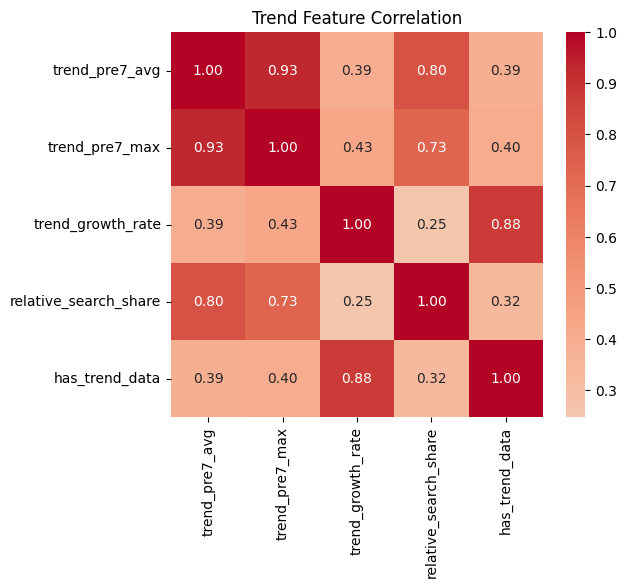

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(trend_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Trend Feature Correlation")
plt.show()

In [15]:
df.groupby("has_trend_data")["log_audience"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std"
)

,count,mean,median,std
has_trend_data,,,,
0,1449,12.008337,12.014246,2.018546
1,2420,11.063676,10.806176,2.216082


In [16]:
trend_df = df[df["has_trend_data"] == 1]

trend_df[
    ["trend_pre7_avg", "trend_pre7_max", "trend_growth_rate", "relative_search_share", "log_audience"]
].corr()

,trend_pre7_avg,trend_pre7_max,trend_growth_rate,relative_search_share,log_audience
trend_pre7_avg,1.000000,0.918823,0.111604,0.774464,0.416497
trend_pre7_max,0.918823,1.000000,0.174798,0.692761,0.419626
trend_growth_rate,0.111604,0.174798,1.000000,-0.081819,0.044085
relative_search_share,0.774464,0.692761,-0.081819,1.000000,0.346352
log_audience,0.416497,0.419626,0.044085,0.346352,1.000000


In [17]:
trend_keep_cols = [
    "trend_pre7_max",
    "relative_search_share",
    "has_trend_data"
]

In [18]:
# ===========================트렌드 조정 완료=================================
# ===========================날짜 데이터 가공=================================

In [19]:
df["open_day_of_week"].value_counts().sort_index()

open_day_of_week
0.0      15
1.0      73
2.0    1854
3.0    1771
4.0      93
5.0      59
6.0       4
Name: count, dtype: int64

In [20]:
df["release_day_group"] = "other"
df.loc[df["open_day_of_week"] == 2, "release_day_group"] = "wed"
df.loc[df["open_day_of_week"] == 3, "release_day_group"] = "thu"

df["release_day_group"].value_counts()

release_day_group
wed      1854
thu      1771
other     244
Name: count, dtype: int64

In [21]:
df.groupby("release_day_group")["log_audience"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std"
)

,count,mean,median,std
release_day_group,,,,
other,244,11.154320,10.942251,2.238733
thu,1771,11.125402,11.032839,2.098027
wed,1854,11.731087,11.587102,2.231745


In [22]:
df.groupby("release_day_group")["total_audience"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std"
)

,count,mean,median,std
release_day_group,,,,
other,244,541505.356557,56519.5,1.222084e+06
thu,1771,471429.427442,61872.0,1.256591e+06
wed,1854,865170.382416,107699.5,1.893267e+06


In [23]:
day_map = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun",
}

df["open_day_name"] = df["open_day_of_week"].map(day_map)

day_audience_summary = (
    df.groupby(["open_day_of_week", "open_day_name"])["total_audience"]
      .agg(
          movie_count="count",
          mean_audience="mean",
          median_audience="median",
          std_audience="std",
          min_audience="min",
          max_audience="max"
      )
      .reset_index()
      .sort_values("open_day_of_week")
)

day_audience_summary["mean_audience"] = day_audience_summary["mean_audience"].round(0).astype(int)
day_audience_summary["median_audience"] = day_audience_summary["median_audience"].round(0).astype(int)

day_audience_summary

,open_day_of_week,open_day_name,movie_count,mean_audience,median_audience,std_audience,min_audience,max_audience
0,0.0,Mon,15,115011,6166,2.766356e+05,406,811097
1,1.0,Tue,73,1080742,388989,1.668639e+06,259,8006860
2,2.0,Wed,1854,865170,107700,1.893267e+06,310,17583608
3,3.0,Thu,1771,471429,61872,1.256591e+06,260,13766393
4,4.0,Fri,93,453396,46784,1.107860e+06,655,7514196
5,5.0,Sat,59,158097,27283,4.903997e+05,2740,3380750
6,6.0,Sun,4,3608,2958,3.453607e+03,600,7917


In [ ]:

model_wed_base = smf.ols(
    """
    log_audience ~ C(open_day_of_week, Treatment(reference=2))
    + runtime
    + rating_encoded
    + is_korean
    + C(genre)
    + open_month
    + is_summer
    + is_winter
    + is_holiday_release
    + holiday_nearby_count
    + lead_actor_avg_audi
    + lead_actor_movie_count
    + cast_max_star_power
    + distributor_avg_audi
    + distributor_movie_count
    + producer_avg_audi
    + producer_movie_count
    + same_week_releases
    + market_avg_audi_7d
    """,
    data=df
).fit(cov_type="HC3")

print(model_wed_base.summary())

                            OLS Regression Results                            
Dep. Variable:           log_audience   R-squared:                       0.427
Model:                            OLS   Adj. R-squared:                  0.420
Method:                 Least Squares   F-statistic:                     26.81
Date:                Thu, 21 May 2026   Prob (F-statistic):          9.42e-166
Time:                        09:17:23   Log-Likelihood:                -7450.1
No. Observations:                3869   AIC:                         1.499e+04
Df Residuals:                    3825   BIC:                         1.526e+04
Df Model:                          43                                         
Covariance Type:                  HC3                                         
                                                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

c:\Users\playdata\Desktop\workspace\SKN2nd\SKN30-2nd-4Team\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 43, but rank is 38
  warnings.warn('covariance of constraints does not have full '


In [ ]:
# ===========================날짜 잠시 보류(수/목/이외 나눌지)==============================
# ============================power balance 조정=================================

In [27]:
power_cols = [
    "director_avg_audi",
    "director_movie_count",
    "lead_actor_avg_audi",
    "lead_actor_movie_count",
    "cast_max_star_power",
    "distributor_avg_audi",
    "distributor_movie_count",
    "producer_avg_audi",
    "producer_movie_count",
]

df[power_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
director_avg_audi,3869.0,5.076173e+05,1.284385e+06,0.0,0.0,0.000000e+00,3.049787e+05,1.424143e+07
director_movie_count,3869.0,1.257948e+00,2.611751e+00,0.0,0.0,0.000000e+00,1.000000e+00,3.600000e+01
lead_actor_avg_audi,3869.0,1.735273e+06,2.235537e+06,0.0,74944.0,8.098358e+05,2.639875e+06,1.492332e+07
lead_actor_movie_count,3869.0,3.376325e+00,4.154341e+00,0.0,0.0,2.000000e+00,5.000000e+00,3.700000e+01
cast_max_star_power,3869.0,2.441728e+06,3.109134e+06,0.0,91981.0,1.214122e+06,3.661434e+06,1.758361e+07
distributor_avg_audi,3869.0,4.155226e+05,6.059727e+05,0.0,8383.0,1.414025e+05,6.169025e+05,3.880069e+06
distributor_movie_count,3869.0,2.935461e+01,4.020100e+01,0.0,1.0,1.300000e+01,4.100000e+01,2.170000e+02
producer_avg_audi,3869.0,3.050756e+05,1.074553e+06,0.0,0.0,0.000000e+00,0.000000e+00,1.758361e+07
producer_movie_count,3869.0,7.549754e-01,2.982529e+00,0.0,0.0,0.000000e+00,0.000000e+00,1.170000e+02


In [28]:
power_corr = df[power_cols + ["log_audience"]].corr()

power_corr["log_audience"].sort_values(ascending=False)

log_audience               1.000000
lead_actor_avg_audi        0.374657
cast_max_star_power        0.349368
director_avg_audi          0.295021
producer_avg_audi          0.286501
distributor_avg_audi       0.281529
producer_movie_count       0.149955
director_movie_count       0.097780
lead_actor_movie_count     0.086635
distributor_movie_count    0.070326
Name: log_audience, dtype: float64

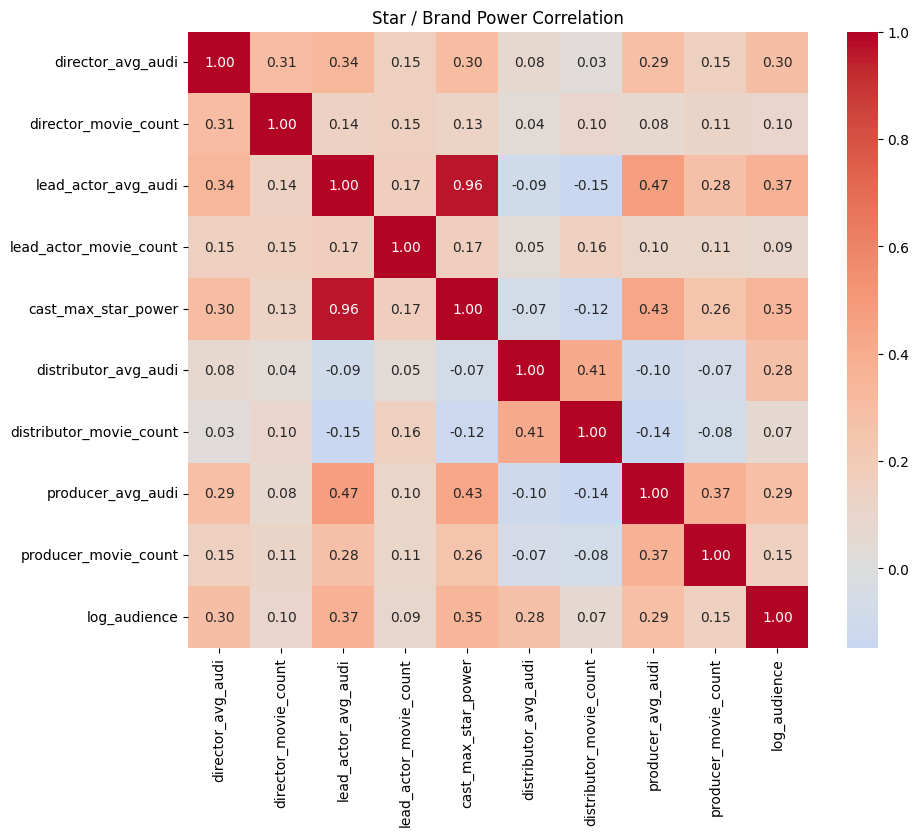

In [29]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    power_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Star / Brand Power Correlation")
plt.show()

In [30]:
# 이력 존재 여부 플래그
df["has_director_history"] = (df["director_movie_count"] > 0).astype(int)
df["has_lead_actor_history"] = (df["lead_actor_movie_count"] > 0).astype(int)
df["has_distributor_history"] = (df["distributor_movie_count"] > 0).astype(int)
df["has_producer_history"] = (df["producer_movie_count"] > 0).astype(int)

# 평균 관객수 계열은 로그 변환
power_audi_cols = [
    "director_avg_audi",
    "lead_actor_avg_audi",
    "distributor_avg_audi",
    "producer_avg_audi",
]

for col in power_audi_cols:
    df[f"{col}_log"] = np.log1p(df[col])

In [31]:
df["has_director_history"].value_counts()

has_director_history
0    2165
1    1704
Name: count, dtype: int64

In [32]:
# ==========================이력 관련 마무리=============================
# ========================공휴일======================================

In [33]:
holiday_cols = [
    "is_holiday_release",
    "holiday_nearby_count",
    "is_summer",
    "is_winter",
    "open_month",
]

df[holiday_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
is_holiday_release,3869.0,0.048591,0.215040,0.0,0.0,0.0,0.0,1.0
holiday_nearby_count,3869.0,0.511243,0.874013,0.0,0.0,0.0,1.0,6.0
is_summer,3869.0,0.158439,0.365199,0.0,0.0,0.0,0.0,1.0
is_winter,3869.0,0.153787,0.360791,0.0,0.0,0.0,0.0,1.0
open_month,3869.0,6.564487,3.433109,1.0,4.0,7.0,10.0,12.0


In [34]:
df.groupby("is_holiday_release")["log_audience"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std"
)

,count,mean,median,std
is_holiday_release,,,,
0,3681,11.385956,11.253909,2.196998
1,188,12.034417,12.016766,2.003505


In [35]:
df.groupby("holiday_nearby_count")["log_audience"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std"
).sort_index()

,count,mean,median,std
holiday_nearby_count,,,,
0,2587,11.305305,11.141760,2.210105
1,800,11.621954,11.565229,2.129746
2,324,11.603672,11.541472,2.139168
3,124,11.879560,11.937531,2.239517
4,18,11.502120,11.871499,1.766689
5,10,11.430644,11.342850,2.112257
6,6,12.631314,12.602709,2.530279


In [36]:
df[holiday_cols + ["log_audience"]].corr()["log_audience"].sort_values(ascending=False)

log_audience            1.000000
is_winter               0.084009
holiday_nearby_count    0.068357
is_summer               0.063863
is_holiday_release      0.063610
open_month              0.007236
Name: log_audience, dtype: float64

In [37]:
# 공휴일 주변 효과를 안정적인 이진 피처로 변환
df["has_nearby_holiday"] = (df["holiday_nearby_count"] > 0).astype(int)

df["has_nearby_holiday"].value_counts()

has_nearby_holiday
0    2587
1    1282
Name: count, dtype: int64

In [38]:
# ========================공휴일 끝===============================
# ========================런타임===============================

In [39]:
df["runtime"].describe()

count    3869.000000
mean      107.200569
std        21.099743
min        20.000000
25%        94.000000
50%       106.000000
75%       119.000000
max       263.000000
Name: runtime, dtype: float64

In [40]:
df["runtime_group"] = pd.cut(
    df["runtime"],
    bins=[0, 80, 100, 120, np.inf],
    labels=["short", "80_100", "100_120", "long"]
)

df.groupby("runtime_group")["log_audience"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std"
)

,count,mean,median,std
runtime_group,,,,
short,307,10.081192,10.019669,1.511836
80_100,1161,10.759479,10.732607,1.902275
100_120,1537,11.598284,11.631473,2.117549
long,864,12.454781,12.719502,2.351795


In [41]:
# 런타임을 구간별로 나누었음

In [42]:
# ===========================런타임 완료============================
# =========================정리된 데이터 정리===========================

In [43]:
df["market_avg_audi_7d_log"] = np.log1p(df["market_avg_audi_7d"])

In [44]:
# 학습에 사용할(가공된) 컬럼

covid_cols = ["is_covid_period"]
season = ["is_peak_season"]
trend_keep_cols = [
    "trend_pre7_max",
    "relative_search_share",
    "has_trend_data"
]

power_log_cols = [
    "director_avg_audi_log",
    "lead_actor_avg_audi_log",
    "distributor_avg_audi_log",
    "producer_avg_audi_log",
]
makers_history_yorn = ["has_producer_history", 'has_distributor_history', 'has_lead_actor_history', 'has_director_history']

holiday_col =["has_nearby_holiday"]
runtime_col = ['runtime_group']

base_binary_cols = [
    "is_korean",
    "is_holiday_release",
]

base_categorical_cols = [
    "genre",
    "open_day_of_week",   
]

base_numeric_cols = [
    "rating_encoded",
    "open_year",          # 네가 연도 유지하기로 한 경우
    "holiday_nearby_count",
    "same_week_releases",
    "market_avg_audi_7d_log",
]

In [45]:
target_col = "log_audience"

final_feature_cols = (
    covid_cols
    + season
    + trend_keep_cols
    + power_log_cols
    + makers_history_yorn
    + holiday_col
    + runtime_col
    + base_binary_cols
    + base_categorical_cols
    + base_numeric_cols
)

X = df[final_feature_cols].copy()
y = df[target_col]

### 학습1: 회귀

In [46]:
# 마지막 셀에서 만든 X, y 사용
X_model = X.copy()
y_model = y.copy()

# 원핫인코딩할 범주형 컬럼을 명시적으로 지정
categorical_features = [
    "is_covid_period",
    "is_peak_season",
    "has_trend_data",
    "has_producer_history",
    "has_distributor_history",
    "has_lead_actor_history",
    "has_director_history",
    "has_nearby_holiday",
    "is_korean",
    "is_holiday_release",
    "genre",
    "open_day_of_week",
    "runtime_group",
]

# 나머지는 수치형 컬럼으로 사용
numeric_features = [
    col for col in X_model.columns
    if col not in categorical_features
]


Epoch 001 | train_loss: 66.8382 | val_loss: 5.9506
Epoch 010 | train_loss: 4.5453 | val_loss: 2.3273
Epoch 020 | train_loss: 3.6338 | val_loss: 2.0196
Epoch 030 | train_loss: 3.4478 | val_loss: 2.0201
Epoch 040 | train_loss: 3.0222 | val_loss: 2.2203
Early stopping at epoch 44


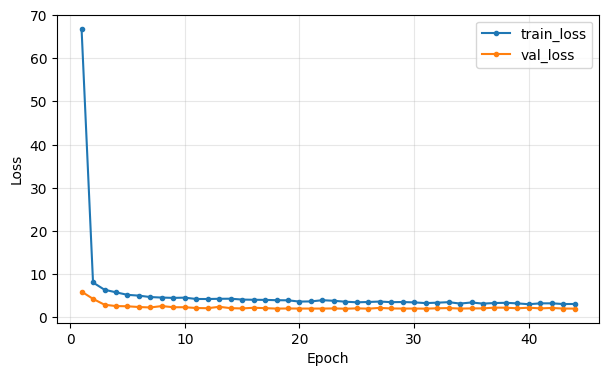

Validation Regression Metrics
MSE : 2.007274627685547
RMSE: 1.4167831971355205
MAE : 1.1288139820098877
R2  : 0.5725902915000916

Original Audience Scale
MAE : 550732.3125
RMSE: 1614205.9243504219


In [47]:
# =========================== Deep Learning Regression ===========================

# 마지막 셀에서 만든 X, y 사용
X_model = X.copy()
y_model = y.copy()

# 원핫인코딩할 범주형 컬럼을 명시적으로 지정
categorical_features = [
    "is_covid_period",
    "is_peak_season",
    "has_trend_data",
    "has_producer_history",
    "has_distributor_history",
    "has_lead_actor_history",
    "has_director_history",
    "has_nearby_holiday",
    "is_korean",
    "is_holiday_release",
    "genre",
    "open_day_of_week",
    "runtime_group",
]

# 나머지는 수치형 컬럼으로 사용
numeric_features = [
    col for col in X_model.columns
    if col not in categorical_features
]



# train / validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42
)

# 수치형: StandardScaler
# 범주형: OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop"
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

train_loader, x_val_tensor, y_val_tensor = make_DataSet(
    X_train_processed,
    X_val_processed,
    y_train,
    y_val,
    batch_size=32
)

class AudienceRegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_processed.shape[1]

model = AudienceRegressionMLP(input_dim).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 200
patience = 20
best_val_loss = np.inf
best_model_state = None
wait = 0

tr_loss_list = []
val_loss_list = []

for epoch in range(1, epochs + 1):
    train_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss, val_pred = evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device)

    tr_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}")

    if wait >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(best_model_state)

dl_learning_curve(tr_loss_list, val_loss_list)

final_val_loss, final_val_pred = evaluate(
    x_val_tensor,
    y_val_tensor,
    model,
    loss_fn,
    device
)

y_val_true = y_val_tensor.cpu().numpy().flatten()
y_val_pred = final_val_pred.cpu().numpy().flatten()

mse = mean_squared_error(y_val_true, y_val_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val_true, y_val_pred)
r2 = r2_score(y_val_true, y_val_pred)

print("Validation Regression Metrics")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

audience_true = np.expm1(y_val_true)
audience_pred = np.expm1(y_val_pred)

audience_mae = mean_absolute_error(audience_true, audience_pred)
audience_rmse = np.sqrt(mean_squared_error(audience_true, audience_pred))

print("\nOriginal Audience Scale")
print("MAE :", audience_mae)
print("RMSE:", audience_rmse)



### 학습2: 회귀 
- 원핫인코딩 컬럼 변경

In [48]:
# 마지막 셀에서 만든 X, y 사용
X_model = X.copy()
y_model = y.copy()

# 원핫인코딩할 범주형 컬럼을 명시적으로 지정
categorical_features = [
    "genre",
    "open_day_of_week",
    "runtime_group",
]

# 나머지는 수치형 컬럼으로 사용
numeric_features = [
    col for col in X_model.columns
    if col not in categorical_features
]


Epoch 001 | train_loss: 48.5951 | val_loss: 4.6652
Epoch 010 | train_loss: 4.0734 | val_loss: 2.0747
Epoch 020 | train_loss: 3.4182 | val_loss: 2.0171
Epoch 030 | train_loss: 2.9735 | val_loss: 1.9844
Epoch 040 | train_loss: 2.7365 | val_loss: 2.0242
Epoch 050 | train_loss: 2.4760 | val_loss: 2.0030
Epoch 060 | train_loss: 2.2480 | val_loss: 2.0070
Early stopping at epoch 61


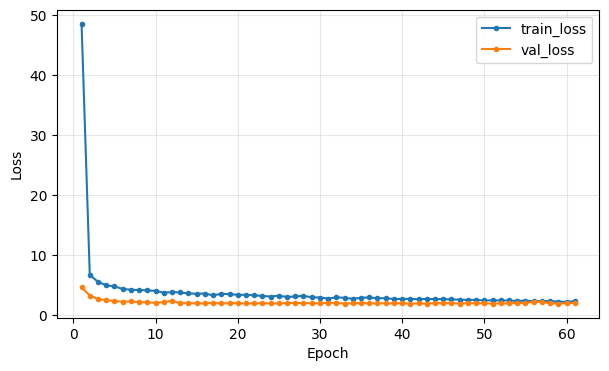

Validation Regression Metrics
MSE : 2.0990517139434814
RMSE: 1.4488104478997526
MAE : 1.147212028503418
R2  : 0.5530481338500977

Original Audience Scale
MAE : 548345.5625
RMSE: 1602172.599820631


In [49]:
# =========================== Deep Learning Regression ===========================

# 마지막 셀에서 만든 X, y 사용
X_model = X.copy()
y_model = y.copy()

# 원핫인코딩할 범주형 컬럼을 명시적으로 지정
categorical_features = [
    "genre",
    "open_day_of_week",
    "runtime_group",
]

# 나머지는 수치형 컬럼으로 사용
numeric_features = [
    col for col in X_model.columns
    if col not in categorical_features
]



# train / validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42
)

# 수치형: StandardScaler
# 범주형: OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop"
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

train_loader, x_val_tensor, y_val_tensor = make_DataSet(
    X_train_processed,
    X_val_processed,
    y_train,
    y_val,
    batch_size=32
)

class AudienceRegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_processed.shape[1]

model = AudienceRegressionMLP(input_dim).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 200
patience = 20
best_val_loss = np.inf
best_model_state = None
wait = 0

tr_loss_list = []
val_loss_list = []

for epoch in range(1, epochs + 1):
    train_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss, val_pred = evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device)

    tr_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}")

    if wait >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(best_model_state)

dl_learning_curve(tr_loss_list, val_loss_list)

final_val_loss, final_val_pred = evaluate(
    x_val_tensor,
    y_val_tensor,
    model,
    loss_fn,
    device
)

y_val_true = y_val_tensor.cpu().numpy().flatten()
y_val_pred = final_val_pred.cpu().numpy().flatten()

mse = mean_squared_error(y_val_true, y_val_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val_true, y_val_pred)
r2 = r2_score(y_val_true, y_val_pred)

print("Validation Regression Metrics")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

audience_true = np.expm1(y_val_true)
audience_pred = np.expm1(y_val_pred)

audience_mae = mean_absolute_error(audience_true, audience_pred)
audience_rmse = np.sqrt(mean_squared_error(audience_true, audience_pred))

print("\nOriginal Audience Scale")
print("MAE :", audience_mae)
print("RMSE:", audience_rmse)

# torch.save(model.state_dict(), "models/audience_Regression_mlp_pre3.pth")

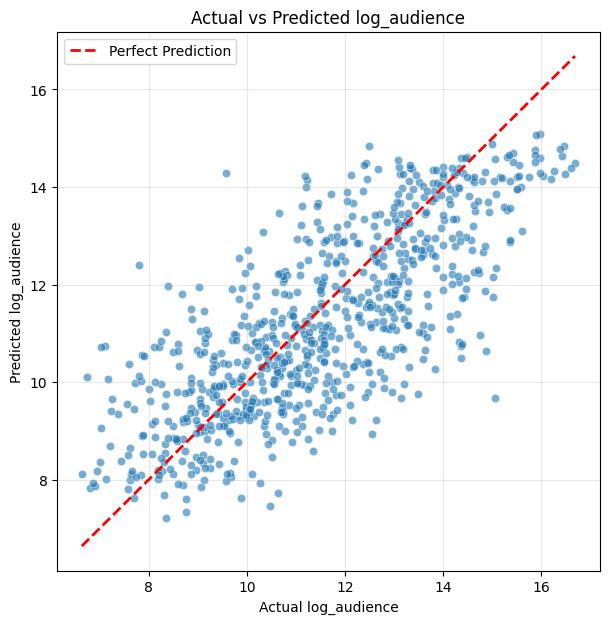

In [50]:
# =========================== Regression Visualization ===========================

# y_val_true, y_val_pred가 이미 있으면 바로 사용 가능
# 없으면 아래 두 줄부터 실행
# y_val_true = y_val_tensor.cpu().numpy().flatten()
# y_val_pred = final_val_pred.cpu().numpy().flatten()

plt.figure(figsize=(7, 7))

sns.scatterplot(
    x=y_val_true,
    y=y_val_pred,
    alpha=0.6
)

min_value = min(y_val_true.min(), y_val_pred.min())
max_value = max(y_val_true.max(), y_val_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual log_audience")
plt.ylabel("Predicted log_audience")
plt.title("Actual vs Predicted log_audience")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 학습3: 분류

class_to_idx: {np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3}
num_classes: 4
Epoch 001 | train_loss: 0.6734 | val_loss: 0.5096 | val_acc: 0.8372
Epoch 010 | train_loss: 0.4130 | val_loss: 0.4285 | val_acc: 0.8385
Epoch 020 | train_loss: 0.3691 | val_loss: 0.4189 | val_acc: 0.8359
Epoch 030 | train_loss: 0.3395 | val_loss: 0.4400 | val_acc: 0.8320
Early stopping at epoch 30


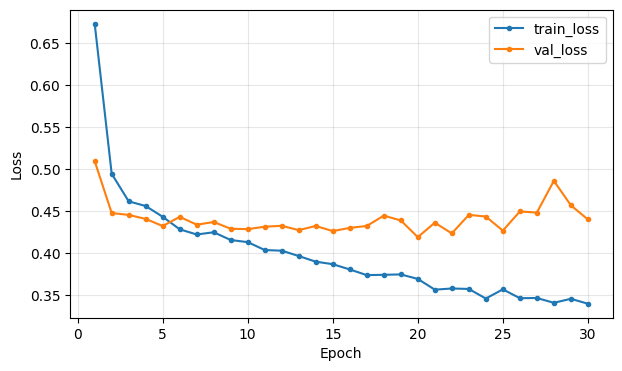

Validation Classification Metrics
Accuracy : 0.8320413436692506
Precision: 0.7983561131510948
Recall   : 0.8320413436692506
F1-score : 0.8132218276022344

Confusion Matrix
[[612  26   0  10]
 [ 49  22   0  10]
 [ 15   6   0   2]
 [  8   3   1  10]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       648
           1       0.39      0.27      0.32        81
           2       0.00      0.00      0.00        23
           3       0.31      0.45      0.37        22

    accuracy                           0.83       774
   macro avg       0.40      0.42      0.40       774
weighted avg       0.80      0.83      0.81       774



In [51]:
# =========================== Deep Learning Classification ===========================

# 마지막 셀에서 만든 final_feature_cols 기준 사용
X_cls = df[final_feature_cols].copy()
y_cls = df["hit_class"].copy()

# 원핫인코딩 대상
onehot_features = [
    "is_covid_period",
    "is_peak_season",
    "has_trend_data",
    "has_producer_history",
    "has_distributor_history",
    "has_lead_actor_history",
    "has_director_history",
    "has_nearby_holiday",
    "is_korean",
    "is_holiday_release",
    "genre",
    "open_day_of_week",
    "runtime_group",
]

# 스케일링 대상
scale_features = [
    col for col in X_cls.columns
    if col not in onehot_features
]


# class label 정리
# hit_class가 문자열이면 숫자 라벨로 변환
if not pd.api.types.is_numeric_dtype(y_cls):
    class_names = sorted(y_cls.dropna().unique())
    class_to_idx = {label: idx for idx, label in enumerate(class_names)}
    idx_to_class = {idx: label for label, idx in class_to_idx.items()}
    y_cls_encoded = y_cls.map(class_to_idx)
else:
    class_names = sorted(y_cls.dropna().unique())
    class_to_idx = {label: idx for idx, label in enumerate(class_names)}
    idx_to_class = {idx: label for label, idx in class_to_idx.items()}
    y_cls_encoded = y_cls.map(class_to_idx)

num_classes = len(class_names)

print("class_to_idx:", class_to_idx)
print("num_classes:", num_classes)

# train / validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_cls,
    y_cls_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_cls_encoded
)

# 전처리
preprocessor_cls = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), scale_features),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), onehot_features),
    ],
    remainder="drop"
)

X_train_processed = preprocessor_cls.fit_transform(X_train)
X_val_processed = preprocessor_cls.transform(X_val)

# TensorDataset / DataLoader 생성
x_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

x_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

class AudienceClassificationMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)


def train_classification(dataloader, model, loss_fn, optimizer, device):
    model.train()
    total_loss = 0

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(dataloader.dataset)


def evaluate_classification(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()

    with torch.no_grad():
        x = x_val_tensor.to(device)
        y = y_val_tensor.to(device)

        pred = model(x)
        loss = loss_fn(pred, y).item()

    return loss, pred


seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_processed.shape[1]

model_cls = AudienceClassificationMLP(input_dim, num_classes).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cls.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 200
patience = 10
best_val_loss = np.inf
best_model_state = None
wait = 0

tr_loss_list = []
val_loss_list = []

for epoch in range(1, epochs + 1):
    train_loss = train_classification(
        train_loader,
        model_cls,
        loss_fn,
        optimizer,
        device
    )

    val_loss, val_pred = evaluate_classification(
        x_val_tensor,
        y_val_tensor,
        model_cls,
        loss_fn,
        device
    )

    tr_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model_cls.state_dict()
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        val_pred_class = torch.argmax(val_pred, dim=1).cpu().numpy()
        val_acc = accuracy_score(y_val, val_pred_class)

        print(
            f"Epoch {epoch:03d} | "
            f"train_loss: {train_loss:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f}"
        )

    if wait >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

model_cls.load_state_dict(best_model_state)

# 학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)

# 최종 검증 평가
final_val_loss, final_val_pred = evaluate_classification(
    x_val_tensor,
    y_val_tensor,
    model_cls,
    loss_fn,
    device
)

y_val_true = y_val_tensor.cpu().numpy()
y_val_pred = torch.argmax(final_val_pred, dim=1).cpu().numpy()

acc = accuracy_score(y_val_true, y_val_pred)
precision = precision_score(y_val_true, y_val_pred, average="weighted", zero_division=0)
recall = recall_score(y_val_true, y_val_pred, average="weighted", zero_division=0)
f1 = f1_score(y_val_true, y_val_pred, average="weighted", zero_division=0)

print("Validation Classification Metrics")
print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nConfusion Matrix")
print(confusion_matrix(y_val_true, y_val_pred))

print("\nClassification Report")
print(
    classification_report(
        y_val_true,
        y_val_pred,
        target_names=[str(idx_to_class[i]) for i in range(num_classes)],
        zero_division=0
    )
)


### 학습 5: 분류 가중치 추가

class_to_idx: {np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3}
num_classes: 4
class_counts
hit_class
0    2591
1     325
2      92
3      87
Name: count, dtype: int64
class_weights
tensor([0.2986, 2.3808, 8.4103, 8.8937])
Epoch 001 | train_loss: 1.2976 | val_loss: 1.2277 | val_acc: 0.7222
Early stopping at epoch 9


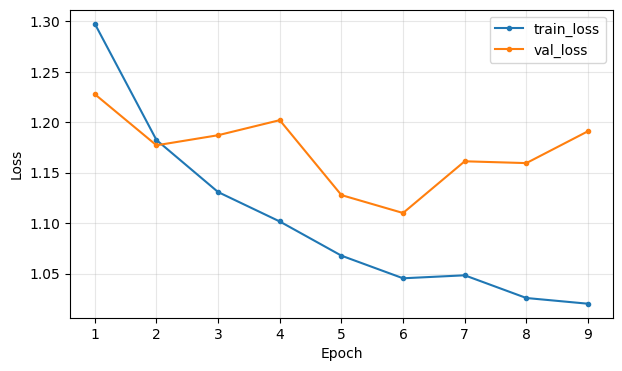

Validation Classification Metrics
Accuracy : 0.7545219638242894
Precision: 0.837023096015193
Recall   : 0.7545219638242894
F1-score : 0.7860085325094726

Confusion Matrix
[[532  81   5  30]
 [ 19  38   5  19]
 [  3  10   1   9]
 [  3   4   2  13]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.82      0.88       648
           1       0.29      0.47      0.36        81
           2       0.08      0.04      0.06        23
           3       0.18      0.59      0.28        22

    accuracy                           0.75       774
   macro avg       0.38      0.48      0.39       774
weighted avg       0.84      0.75      0.79       774



In [52]:
# =========================== Deep Learning Classification ===========================

X_cls = df[final_feature_cols].copy()
y_cls = df["hit_class"].copy()

onehot_features = [
    "is_covid_period",
    "is_peak_season",
    "has_trend_data",
    "has_producer_history",
    "has_distributor_history",
    "has_lead_actor_history",
    "has_director_history",
    "has_nearby_holiday",
    "is_korean",
    "is_holiday_release",
    "genre",
    "open_day_of_week",
    "runtime_group",
]

scale_features = [
    col for col in X_cls.columns
    if col not in onehot_features
]

X_cls[scale_features] = X_cls[scale_features].fillna(0)

X_cls[onehot_features] = (
    X_cls[onehot_features]
    .astype(str)
    .fillna("missing")
)

# hit_class를 0부터 시작하는 정수 라벨로 정리
class_names = sorted(y_cls.dropna().unique())
class_to_idx = {label: idx for idx, label in enumerate(class_names)}
idx_to_class = {idx: label for label, idx in class_to_idx.items()}

y_cls_encoded = y_cls.map(class_to_idx)

num_classes = len(class_names)

print("class_to_idx:", class_to_idx)
print("num_classes:", num_classes)

X_train, X_val, y_train, y_val = train_test_split(
    X_cls,
    y_cls_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_cls_encoded
)

preprocessor_cls = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), scale_features),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), onehot_features),
    ],
    remainder="drop"
)

X_train_processed = preprocessor_cls.fit_transform(X_train)
X_val_processed = preprocessor_cls.transform(X_val)

x_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

x_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

class AudienceClassificationMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)


seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_processed.shape[1]

model_cls = AudienceClassificationMLP(input_dim, num_classes).to(device)

# 클래스 불균형 보정용 가중치
class_counts = y_train.value_counts().sort_index()

class_weights = len(y_train) / (len(class_counts) * class_counts)
class_weights = torch.tensor(
    class_weights.values,
    dtype=torch.float32
).to(device)

print("class_counts")
print(class_counts)

print("class_weights")
print(class_weights)

loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model_cls.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 200
patience = 3
best_val_loss = np.inf
best_model_state = None
wait = 0

tr_loss_list = []
val_loss_list = []

for epoch in range(1, epochs + 1):
    train_loss = train(
        train_loader,
        model_cls,
        loss_fn,
        optimizer,
        device
    )

    val_loss, val_pred = evaluate(
        x_val_tensor,
        y_val_tensor,
        model_cls,
        loss_fn,
        device
    )

    tr_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model_cls.state_dict()
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        y_val_pred = torch.argmax(val_pred, dim=1).cpu().numpy()
        val_acc = accuracy_score(y_val, y_val_pred)

        print(
            f"Epoch {epoch:03d} | "
            f"train_loss: {train_loss:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f}"
        )

    if wait >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

model_cls.load_state_dict(best_model_state)

dl_learning_curve(tr_loss_list, val_loss_list)

final_val_loss, final_val_pred = evaluate(
    x_val_tensor,
    y_val_tensor,
    model_cls,
    loss_fn,
    device
)

y_val_true = y_val_tensor.cpu().numpy()
y_val_pred = torch.argmax(final_val_pred, dim=1).cpu().numpy()

acc = accuracy_score(y_val_true, y_val_pred)
precision = precision_score(
    y_val_true,
    y_val_pred,
    average="weighted",
    zero_division=0
)
recall = recall_score(
    y_val_true,
    y_val_pred,
    average="weighted",
    zero_division=0
)
f1 = f1_score(
    y_val_true,
    y_val_pred,
    average="weighted",
    zero_division=0
)

print("Validation Classification Metrics")
print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nConfusion Matrix")
print(confusion_matrix(y_val_true, y_val_pred))

print("\nClassification Report")
print(
    classification_report(
        y_val_true,
        y_val_pred,
        target_names=[str(idx_to_class[i]) for i in range(num_classes)],
        zero_division=0
    )
)

# torch.save(model_cls.state_dict(), "models/audience_classification_weighted_pre3.pth")

### 학습6 회귀: 가중치 포함

class_counts
hit_class
0    2591
1     325
2      92
3      87
Name: count, dtype: int64

class_weights
hit_class
0    0.298630
1    2.380769
2    8.410326
3    8.893678
Name: count, dtype: float64
Epoch 001 | train_weighted_mse: 112.4615 | val_weighted_mse: 14.4614
Epoch 010 | train_weighted_mse: 5.7695 | val_weighted_mse: 2.3648
Epoch 020 | train_weighted_mse: 4.9921 | val_weighted_mse: 1.8429
Epoch 030 | train_weighted_mse: 4.9625 | val_weighted_mse: 2.8252
Epoch 040 | train_weighted_mse: 3.9002 | val_weighted_mse: 1.8959
Epoch 050 | train_weighted_mse: 3.8699 | val_weighted_mse: 1.5985
Epoch 060 | train_weighted_mse: 3.4934 | val_weighted_mse: 1.6058
Epoch 070 | train_weighted_mse: 3.1007 | val_weighted_mse: 2.1773
Epoch 080 | train_weighted_mse: 2.8990 | val_weighted_mse: 1.6925
Early stopping at epoch 82


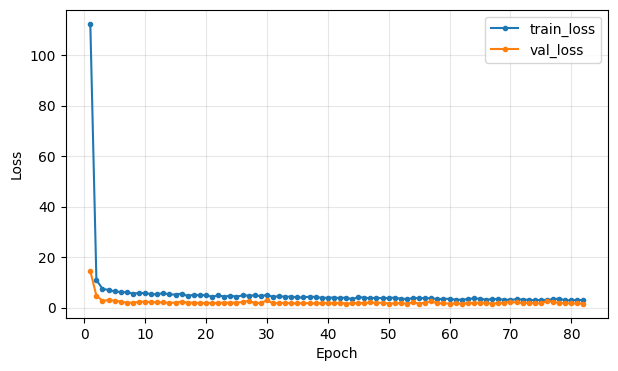

Validation Regression Metrics
MSE : 2.948481798171997
RMSE: 1.7171143812140173
MAE : 1.3193292617797852
R2  : 0.41213756799697876

Original Audience Scale
MAE : 839241.4375
RMSE: 1756559.105669946


In [53]:
# =========================== Weighted Deep Learning Regression ===========================

X_reg = df[final_feature_cols].copy()
y_reg = df["log_audience"].copy()
weight_base = df["hit_class"].copy()

onehot_features = [
    "is_covid_period",
    "is_peak_season",
    "has_trend_data",
    "has_producer_history",
    "has_distributor_history",
    "has_lead_actor_history",
    "has_director_history",
    "has_nearby_holiday",
    "is_korean",
    "is_holiday_release",
    "genre",
    "open_day_of_week",
    "runtime_group",
]

scale_features = [
    col for col in X_reg.columns
    if col not in onehot_features
]

X_train, X_val, y_train, y_val, hit_train, hit_val = train_test_split(
    X_reg,
    y_reg,
    weight_base,
    test_size=0.2,
    random_state=42,
    stratify=weight_base
)

preprocessor_reg = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), scale_features),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), onehot_features),
    ],
    remainder="drop"
)

X_train_processed = preprocessor_reg.fit_transform(X_train)
X_val_processed = preprocessor_reg.transform(X_val)

# hit_class 빈도 기반 sample weight 생성
class_counts = hit_train.value_counts().sort_index()
class_weights = len(hit_train) / (len(class_counts) * class_counts)

sample_weights_train = hit_train.map(class_weights)
sample_weights_val = hit_val.map(class_weights)

print("class_counts")
print(class_counts)

print("\nclass_weights")
print(class_weights)

x_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
w_train_tensor = torch.tensor(sample_weights_train.values, dtype=torch.float32).view(-1, 1)

x_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
w_val_tensor = torch.tensor(sample_weights_val.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(
    x_train_tensor,
    y_train_tensor,
    w_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

class AudienceWeightedRegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


def train_weighted_regression(dataloader, model, optimizer, device):
    model.train()
    total_loss = 0
    total_weight = 0

    for x, y, w in dataloader:
        x = x.to(device)
        y = y.to(device)
        w = w.to(device)

        optimizer.zero_grad()

        pred = model(x)

        loss_each = (pred - y) ** 2
        loss = (loss_each * w).sum() / w.sum()

        loss.backward()
        optimizer.step()

        total_loss += (loss_each * w).sum().item()
        total_weight += w.sum().item()

    return total_loss / total_weight


def evaluate_weighted_regression(x_val_tensor, y_val_tensor, w_val_tensor, model, device):
    model.eval()

    with torch.no_grad():
        x = x_val_tensor.to(device)
        y = y_val_tensor.to(device)
        w = w_val_tensor.to(device)

        pred = model(x)

        loss_each = (pred - y) ** 2
        loss = (loss_each * w).sum() / w.sum()

    return loss.item(), pred


seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_processed.shape[1]

model_reg = AudienceWeightedRegressionMLP(input_dim).to(device)

optimizer = optim.Adam(
    model_reg.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

epochs = 200
patience = 20
best_val_loss = np.inf
best_model_state = None
wait = 0

tr_loss_list = []
val_loss_list = []

for epoch in range(1, epochs + 1):
    train_loss = train_weighted_regression(
        train_loader,
        model_reg,
        optimizer,
        device
    )

    val_loss, val_pred = evaluate_weighted_regression(
        x_val_tensor,
        y_val_tensor,
        w_val_tensor,
        model_reg,
        device
    )

    tr_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model_reg.state_dict()
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train_weighted_mse: {train_loss:.4f} | "
            f"val_weighted_mse: {val_loss:.4f}"
        )

    if wait >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

model_reg.load_state_dict(best_model_state)

dl_learning_curve(tr_loss_list, val_loss_list)

final_val_loss, final_val_pred = evaluate_weighted_regression(
    x_val_tensor,
    y_val_tensor,
    w_val_tensor,
    model_reg,
    device
)

y_val_true = y_val_tensor.cpu().numpy().flatten()
y_val_pred = final_val_pred.cpu().numpy().flatten()

mse = mean_squared_error(y_val_true, y_val_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val_true, y_val_pred)
r2 = r2_score(y_val_true, y_val_pred)

print("Validation Regression Metrics")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

audience_true = np.expm1(y_val_true)
audience_pred = np.expm1(y_val_pred)

audience_mae = mean_absolute_error(audience_true, audience_pred)
audience_rmse = np.sqrt(mean_squared_error(audience_true, audience_pred))

print("\nOriginal Audience Scale")
print("MAE :", audience_mae)
print("RMSE:", audience_rmse)

# torch.save(model_reg.state_dict(), "models/audience_weighted_regression_mlp.pth")